## Задача 1

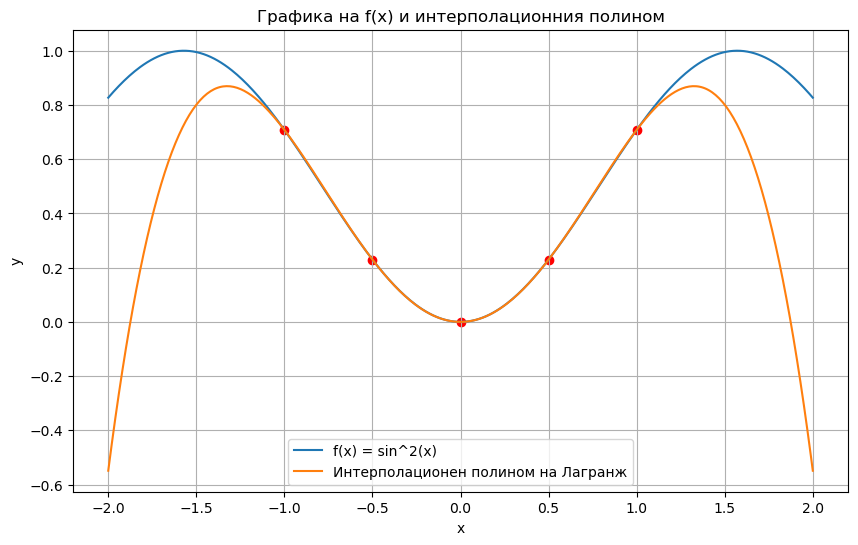

(-0.5488578467480991, 0.8268218104318058, 1.6638163626349667)

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Дефиниране на функцията f(x) = sin^2(x)
def f(x):
    return np.sin(x) ** 2

# Функция за интерполация на Лагранж
def lagrange_interpolation(x, x_values, y_values):
    n = len(x_values)
    result = np.zeros_like(x, dtype=np.float64)
    for i in range(n):
        term = y_values[i]
        for j in range(n):
            if i != j:
                term *= (x - x_values[j]) / (x_values[i] - x_values[j])
        result += term
    return result

# Генериране на 5 равноотдалечени точки в интервала [-1, 1]
x_points = np.linspace(-1, 1, 5)
y_points = f(x_points)

# Генериране на точки за визуализация
x_range = np.linspace(-2, 2, 400)
f_values = f(x_range)
interpolated_values = lagrange_interpolation(x_range, x_points, y_points)

# Изчисление на стойността на интерполационния полином при x = 2
approx_value = lagrange_interpolation(np.array([2]), x_points, y_points)[0]
true_value = f(2)
relative_error = np.abs(approx_value - true_value) / np.abs(true_value)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(x_range, f_values, label="f(x) = sin^2(x)")
plt.plot(x_range, interpolated_values, label="Интерполационен полином на Лагранж")
plt.scatter(x_points, y_points, color='red')
plt.title("Графика на f(x) и интерполационния полином")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

approx_value, true_value, relative_error

### Обяснение на получения резултат

Интерполационният полином приближава добре функцията ***f(x)*** в зададения интервал. Обаче, когато пресмятаме стойността на интерполационния полином при ***x = 2***, получаваме голямо различие спрямо истинската стойност на функцията ***f(2)***.

Стойността на интерполационния полином при ***x = 2*** е приблизително ***−0.5489***, докато истинската стойност на ***f(2) = sin^2(2)*** е ***0.8268***. Относителната грешка на това приближение е много голяма - над ***100%***. Тази голяма грешка се дължи на факта, че интерполационният полином е проектиран да дава добри резултати в интервала ***[-1, 1]***, а стойността ***x = 2*** е извън този интервал.

## Задача 2

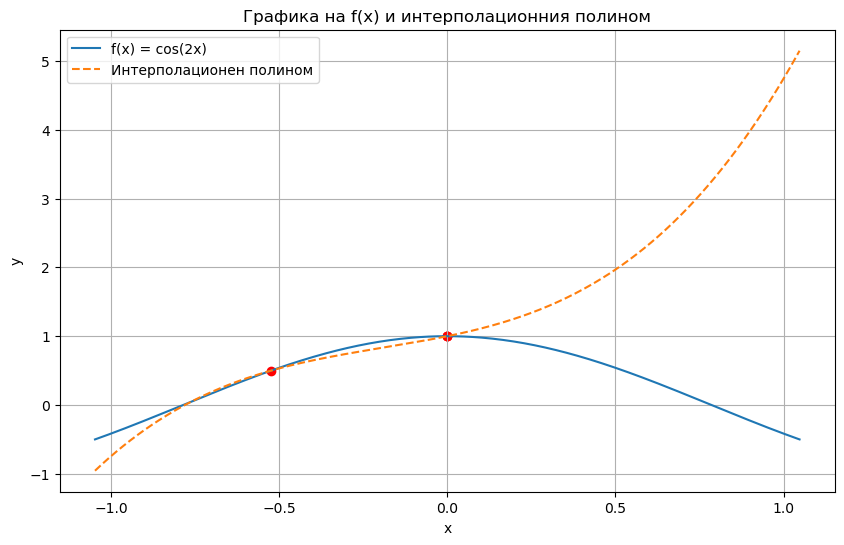

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def divided_difference(nodes, values):
    n = len(nodes)
    
    if n == 1:
        return values[0]
    
    return (divided_difference(nodes[1:], values[1:]) - divided_difference(nodes[:-1], values[:-1])) / (nodes[-1] - nodes[0])


def interpolation(x, y, dd, x_new):
    n = len(x)
    result = dd[0, 0]
    for i in range(1, n):
        term = dd[0, i]
        for j in range(i):
            term *= (x_new - x[j])
        result += term
    return result

# Дефиниране на функцията f(x) = cos(2x)
def f(x):
    return np.cos(2 * x)

# Дефиниране на възлите с техните кратности
nodes = np.array([-(np.pi/6), 0, 0, 0])
values = np.array([f(-(np.pi/6)), f(0), f(0), f(0)])

# Изчисляване на разделените разлики
dd_table = divided_differences(nodes, values)

# Генериране на точки за визуализация
x_range = np.linspace(-np.pi/3, np.pi/3, 400)
f_values = f(x_range)
interpolated_values = [interpolation(nodes, values, dd_table, x) for x in x_range]

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(x_range, f_values, label="f(x) = cos(2x)")
plt.plot(x_range, interpolated_values, label="Интерполационен полином", linestyle='dashed')
plt.scatter(nodes, values, color='red')
plt.title("Графика на f(x) и интерполационния полином")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


## Задача 3

/tmp/ipykernel_283/248452929.py:39: RuntimeWarning: divide by zero encountered in divide
  basis_4 = [lambda x, n=n: 1/(n - x) for n in range(1, 6)]


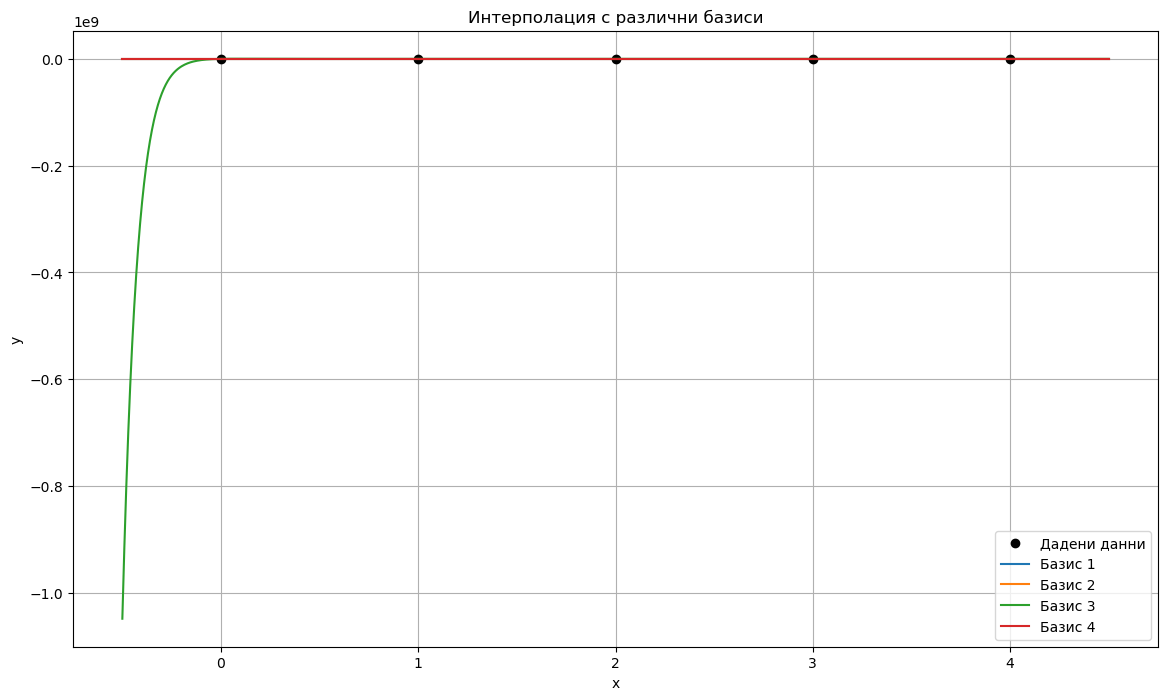

(array([ 4.37706683e+00, -1.71177211e+00,  2.45563429e-01, -1.09871504e-02,
         1.28997854e-04]),
 array([   14.5818,  -167.7456,   746.277 , -1262.3856,   695.142 ]),
 array([ 1.00870517e+00,  2.45518933e+02, -1.13598996e+05,  2.60905227e+06,
        -2.49569690e+06]),
 array([-0. , -0. , -0. , -0. , 14.5]))

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Данни от таблицата
x_data = np.array([0, 1, 2, 3, 4])
y_data = np.array([2.9, 1.32483, 1.088, 1.02778, 1.00956])

# Изчисляване на коофициентите на обобщения полином за всеки от базисите
def compute_coefficients(x, y, basis_functions):
    # Изграждане на матрицата на системата
    matrix = np.zeros((len(x), len(basis_functions)))
    for i, basis in enumerate(basis_functions):
        matrix[:, i] = basis(x)
    
    # Решаване на системата за намиране на коофициентите
    coefficients = np.linalg.solve(matrix, y)
    return coefficients

# Функция за изчисляване на стойностите на обобщения полином
def evaluate_polynomial(x, coefficients, basis_functions):
    result = np.zeros_like(x, dtype=np.float64)
    for coef, basis in zip(coefficients, basis_functions):
        result += coef * basis(x)
    return result

# Първи базис
basis_1 = [lambda x, n=n: np.exp(n*x) for n in range(5)]
coefficients_1 = compute_coefficients(x_data, y_data, basis_1)

# Втори базис
basis_2 = [lambda x, n=n: 1/(n + x) for n in range(1, 6)]
coefficients_2 = compute_coefficients(x_data, y_data, basis_2)

# Трети базис
basis_3 = [lambda x, n=n: np.exp(-n*np.pi*x) for n in range(5)]
coefficients_3 = compute_coefficients(x_data, y_data, basis_3)

# Четвърти базис
basis_4 = [lambda x, n=n: 1/(n - x) for n in range(1, 6)]
coefficients_4 = compute_coefficients(x_data, y_data, basis_4)

# Визуализация на данните и полиномите
x_values = np.linspace(-0.5, 4.5, 1000)
polynomials = [
    evaluate_polynomial(x_values, coefficients_1, basis_1),
    evaluate_polynomial(x_values, coefficients_2, basis_2),
    evaluate_polynomial(x_values, coefficients_3, basis_3),
    evaluate_polynomial(x_values, coefficients_4, basis_4)
]

plt.figure(figsize=(14, 8))
plt.plot(x_data, y_data, 'ko', label='Дадени данни')
plt.plot(x_values, polynomials[0], label='Базис 1')
plt.plot(x_values, polynomials[1], label='Базис 2')
plt.plot(x_values, polynomials[2], label='Базис 3')
plt.plot(x_values, polynomials[3], label='Базис 4')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Интерполация с различни базиси')
plt.grid(True)
plt.show()


(coefficients_1, coefficients_2, coefficients_3, coefficients_4)

### Обяснение на базисите

На ***четвъртия базис коефициентите не могат да бъдат изчислени поради деление на нула при x = 1***, което води до грешка.

## Въпрос 1
***Обяснете как на практика се използва теоремата за оценка на грешката при интерполация***

Теоремата за оценка на грешката ни казва как да намерим макс грешката от интерполацията. Взимаме най-голямата стойност на (n+1)-вата производна на функцията и я умножаваме по произведението на интервалите между точките. Това ни дава представа дали интерполирането е точно или трябва да добавим още точки.

### Въпрос 2
***Колко интерполационни условия са необходими за построяването на тригонометричен полином от ред 4? Обосновете се***

За тригонометричен полином от ред 4 са нужни 8 интерполационни условия, защото имаме 4 косинуса и 4 синуса. Те са по два за всяка функция - един за коефициента пред функцията и един за фазата. Така уравнението става еднозначно определено и можем да намерим всички коефициенти.

### Въпрос 3
***Какво представляват числените методи?***

Числените методи са техники, с които решаваме математически проблеми, които не стават на ум или на хартия. Например, когато не можем да намерим точно решение на уравнение, ползваме числени методи да намерим приближено. Те са яки, защото работят с компютър и ни спасяват, когато математиката стане твърде сложна.

### Въпрос 4
***В какви случаи е по-удобно да се използва интерполационната формула на Лагранж пред тази на Нютон?***

Интерполационната формула на Лагранж е по-добре да се използва, когато имаме малко точки, защото е по-директна и не изисква изчисляването на разделени разлики като при Нютон. Супер е, когато трябва да добавиш или махнеш точки, защото не трябва да преработваш целия полином. Нютон, от друга страна се използва - за повече точки и когато се налага да добавяш нови данни, без да започваш всичко на чисто.

### Въпрос 5
***Какво представляват грешките от закръгляване***

Грешките от закръгляване са все едно смяташ на калкулатор, който показва само до втория знак след десетичната запетая, а всъщност трябват числата до петия знак. Компютърът прави същото – като сметне нещо, то не е с пълна точност, защото пази числата в ограничен брой битове. Така че като прави много сметки, малките грешки се натрупват и понякога могат да объркат резултата доста.